In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


Image shape: (480, 640, 3)


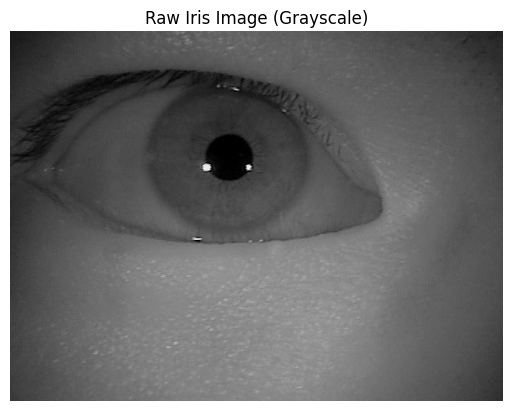

In [2]:
image_path = r"../data/CASIA/CASIA-Iris-Thousand/CASIA-Iris-Thousand/005/L/S5005L00.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image not found. Check dataset path.")

print("Image shape:", image.shape)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Raw Iris Image (Grayscale)")
plt.axis("off")
plt.show()

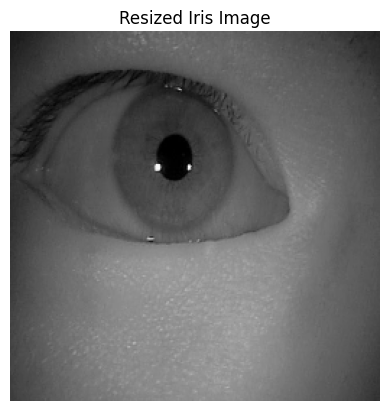

In [3]:
resized = cv2.resize(gray, (256, 256))

plt.imshow(resized, cmap='gray')
plt.title("Resized Iris Image")
plt.axis("off")
plt.show()

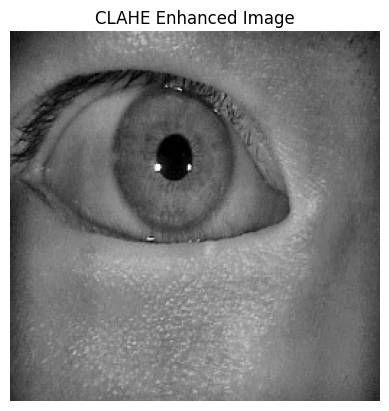

In [4]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(resized)

plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced Image")
plt.axis("off")
plt.show()

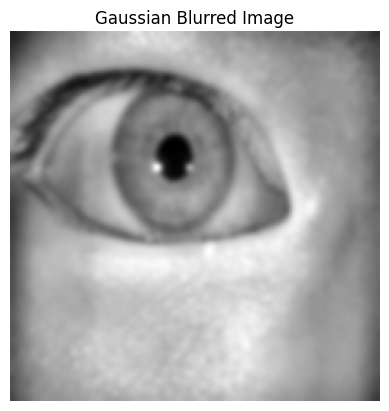

In [5]:
blur = cv2.GaussianBlur(enhanced, (9,9), 2)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

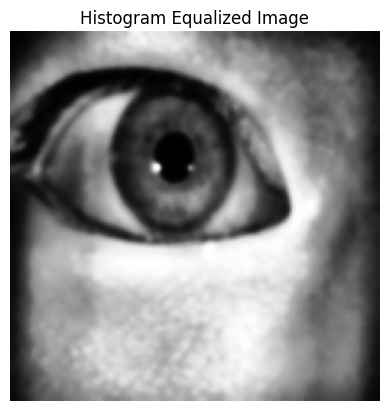

In [6]:
equalized = cv2.equalizeHist(blur)

plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.show()

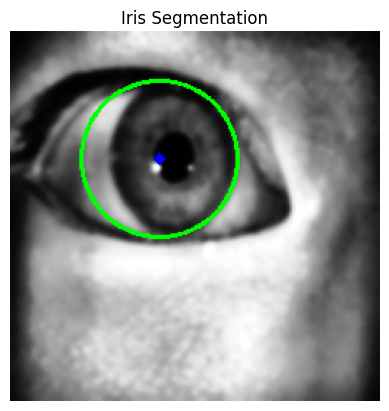

In [7]:
circles = cv2.HoughCircles(
    equalized,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=100,
    param2=30,
    minRadius=40,
    maxRadius=100
)

output = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)

if circles is None:
    raise ValueError("No iris detected. Adjust Hough parameters.")

circles = np.round(circles[0]).astype("int")

x, y, r = circles[0]

cv2.circle(output, (x, y), r, (0, 255, 0), 2)
cv2.circle(output, (x, y), 2, (255, 0, 0), 3)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Iris Segmentation")
plt.axis("off")
plt.show()

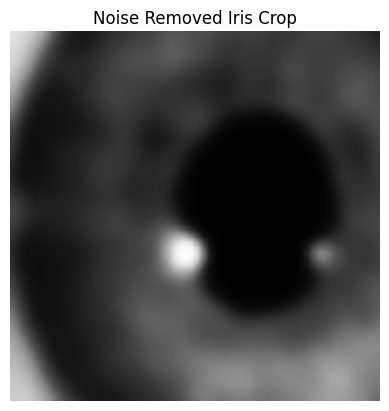

In [8]:
# reduce radius to avoid eyelids/noise
r = int(r * 0.60)

x1 = max(x - r, 0)
y1 = max(y - r, 0)
x2 = min(x + r, equalized.shape[1])
y2 = min(y + r, equalized.shape[0])

iris_crop = equalized[y1:y2, x1:x2]

iris_crop = cv2.resize(iris_crop, (224, 224))

plt.imshow(iris_crop, cmap='gray')
plt.title("Noise Removed Iris Crop")
plt.axis("off")
plt.show()

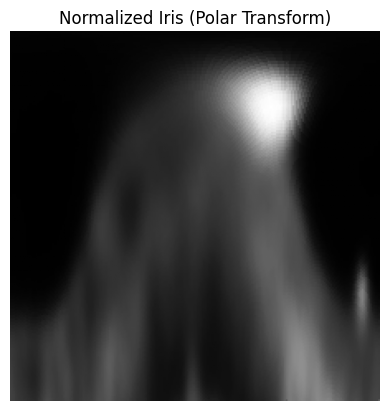

In [9]:
polar_iris = cv2.warpPolar(
    iris_crop,
    (224, 224),
    (112, 112),
    112,
    cv2.WARP_POLAR_LINEAR
)

polar_iris = cv2.rotate(polar_iris, cv2.ROTATE_90_CLOCKWISE)

plt.imshow(polar_iris, cmap='gray')
plt.title("Normalized Iris (Polar Transform)")
plt.axis("off")
plt.show()

In [10]:
cv2.imwrite("../results/week2_results/Raw Iris Image (Grayscale).jpg", gray)

print("Image saved successfully")

Image saved successfully


In [11]:
cv2.imwrite("../results/week2_results/Resized Image.jpg", resized)

print("Image saved successfully")

Image saved successfully


In [12]:
cv2.imwrite("../results/week2_results/Gaussian Blurred Image.jpg", blur)

print("Image saved successfully")

Image saved successfully


In [13]:
cv2.imwrite("../results/week2_results/CLAHE Enhanced Iris.jpg", enhanced)

print("Image saved successfully")

Image saved successfully


In [14]:
cv2.imwrite("../results/week2_results/Histogram Equalization.jpg",equalized)

print("Image saved successfully")

Image saved successfully


In [15]:
cv2.imwrite("../results/week2_results/segmented_iris.jpg", output)

print("Image saved successfully")

Image saved successfully


In [16]:
cv2.imwrite("../results/week2_results/Noise Removed Iris Crop.jpg", iris_crop)

print("Image saved successfully")

Image saved successfully


In [17]:
cv2.imwrite("../results/week2_results/Normalized Polar Iris Image.jpg", polar_iris)

print("Image saved successfully")

Image saved successfully


# Full Dataset Preprocessing Pipeline

In [18]:
import os

dataset_path = "../data/CASIA/CASIA-Iris-Thousand/CASIA-Iris-Thousand"

image_paths = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".jpg"):

            full_path = os.path.join(root, file)

            image_paths.append(full_path)

print("Total images found:", len(image_paths))

Total images found: 20000


In [20]:
from sklearn.model_selection import train_test_split

train_paths, test_paths = train_test_split(
    image_paths,
    test_size=0.15,
    random_state=42
)

train_paths, val_paths = train_test_split(
    train_paths,
    test_size=0.15,
    random_state=42
)

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 14450
Validation images: 2550
Test images: 3000


In [21]:
processed_dataset_path = "../preprocessing"
folders = [
    "train",
    "validation",
    "test"
]

for folder in folders:

    os.makedirs(
        os.path.join(processed_dataset_path, folder),
        exist_ok=True
    )

print("Folders created successfully")

Folders created successfully


In [22]:
def preprocess_iris(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    resized = cv2.resize(gray, (256, 256))

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(resized)

    blur = cv2.GaussianBlur(
        enhanced,
        (9,9),
        2
    )

    equalized = cv2.equalizeHist(blur)

    circles = cv2.HoughCircles(
        equalized,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=80,
        param1=100,
        param2=30,
        minRadius=40,
        maxRadius=100
    )

    if circles is None:
        return None

    circles = np.round(circles[0]).astype("int")

    x, y, r = circles[0]

    r = int(r * 0.60)

    x1 = max(x-r, 0)
    y1 = max(y-r, 0)

    x2 = min(x+r, equalized.shape[1])
    y2 = min(y+r, equalized.shape[0])

    iris_crop = equalized[y1:y2, x1:x2]

    iris_crop = cv2.resize(
        iris_crop,
        (224,224)
    )

    polar_iris = cv2.warpPolar(
        iris_crop,
        (224,224),
        (112,112),
        112,
        cv2.WARP_POLAR_LINEAR
    )

    polar_iris = cv2.rotate(
        polar_iris,
        cv2.ROTATE_90_CLOCKWISE
    )

    return polar_iris

In [23]:
from tqdm import tqdm

for path in tqdm(train_paths):

    processed = preprocess_iris(path)

    if processed is None:
        continue

    filename = os.path.basename(path)

    save_path = os.path.join(
        processed_dataset_path,
        "train",
        filename
    )

    cv2.imwrite(save_path, processed)

print("Train preprocessing completed")

100%|██████████| 14450/14450 [03:41<00:00, 65.24it/s] 

Train preprocessing completed


In [24]:
for path in tqdm(val_paths):

    processed = preprocess_iris(path)

    if processed is None:
        continue

    filename = os.path.basename(path)

    save_path = os.path.join(
        processed_dataset_path,
        "validation",
        filename
    )

    cv2.imwrite(save_path, processed)

print("Validation preprocessing completed")

100%|██████████| 2550/2550 [01:22<00:00, 30.80it/s] 

Validation preprocessing completed


In [25]:
for path in tqdm(test_paths):

    processed = preprocess_iris(path)

    if processed is None:
        continue

    filename = os.path.basename(path)

    save_path = os.path.join(
        processed_dataset_path,
        "test",
        filename
    )

    cv2.imwrite(save_path, processed)

print("Test preprocessing completed")

100%|██████████| 3000/3000 [00:27<00:00, 110.31it/s]

Test preprocessing completed


In [26]:
print("Train images:",
      len(os.listdir("../preprocessing/train")))

print("Validation images:",
      len(os.listdir("../preprocessing/validation")))

print("Test images:",
      len(os.listdir("../preprocessing/test")))

Train images: 14446
Validation images: 2549
Test images: 3000


# Sample Preprocessed Iris Images

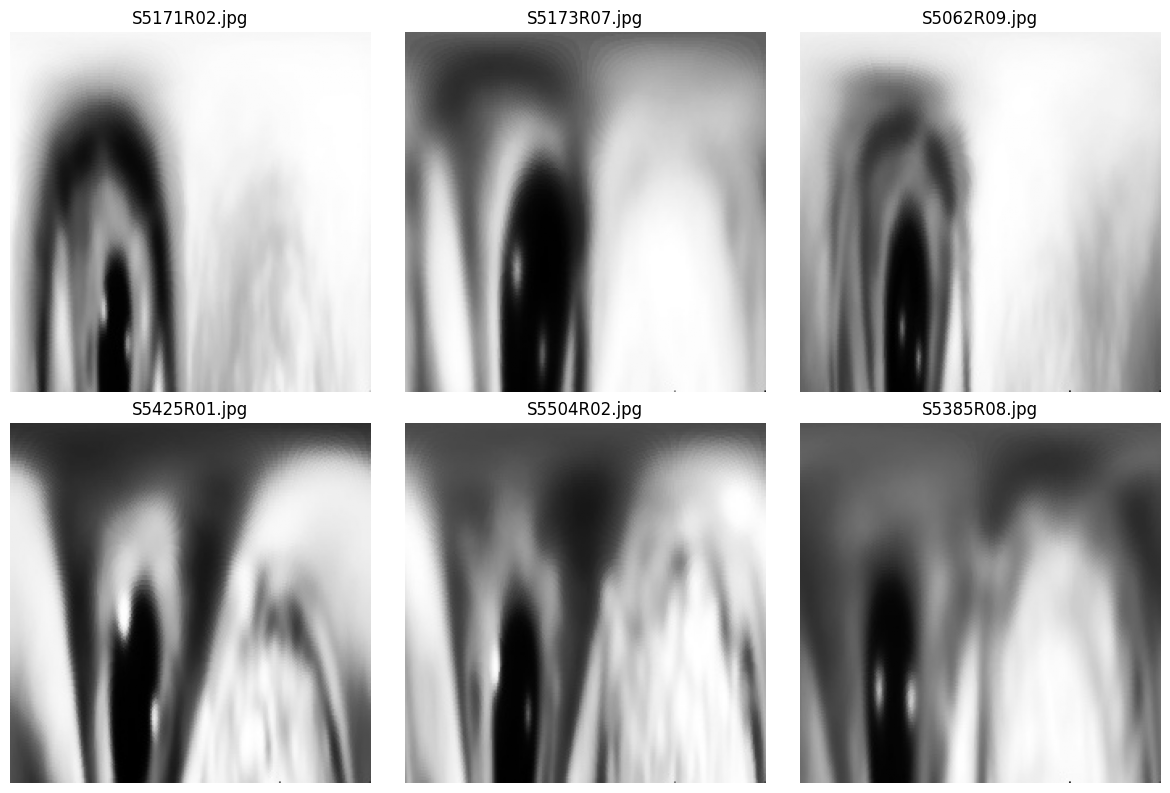

In [27]:
import random
import matplotlib.pyplot as plt

train_folder = "../preprocessing/train"

sample_images = random.sample(
    os.listdir(train_folder),
    6
)

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, img_name in zip(axes.flat, sample_images):

    img_path = os.path.join(
        train_folder,
        img_name
    )

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    ax.imshow(img, cmap="gray")

    ax.set_title(img_name[:12])

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../results/week2_results/sample_preprocessed_images.jpg"
)

plt.show()

# Dataset Split Distribution

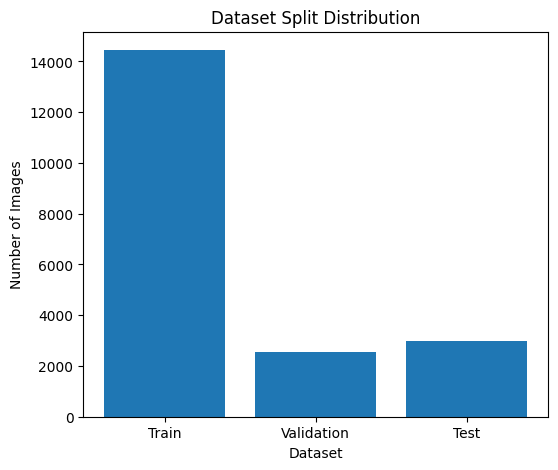

In [28]:
labels = [
    "Train",
    "Validation",
    "Test"
]

counts = [
    len(train_paths),
    len(val_paths),
    len(test_paths)
]

plt.figure(figsize=(6,5))

plt.bar(labels, counts)

plt.title("Dataset Split Distribution")

plt.xlabel("Dataset")

plt.ylabel("Number of Images")

plt.savefig(
    "../results/week2_results/dataset_split_distribution.jpg"
)

plt.show()

# Processed Dataset Summary

In [29]:
print("Train Images:",
      len(os.listdir("../preprocessing/train")))

print("Validation Images:",
      len(os.listdir("../preprocessing/validation")))

print("Test Images:",
      len(os.listdir("../preprocessing/test")))

Train Images: 14446
Validation Images: 2549
Test Images: 3000
